# Visual robustness check: predictions on strongly rotated/augmented images

`val`/`test` splits are evaluated on **plain, unaugmented** crops (deterministic
`build_eval_transform`, see `wings/dataset.py`) -- that's correct for tracking
comparable `val_mean_error_px` across epochs, but it never actually shows what
the model does on the kind of heavily rotated, noisy input it was trained to
handle (`TrainAugmentConfig`, see `jobs/online/README.md`). This notebook runs
inference on **test** images pushed through controlled rotation angles and
through the *actual* config 4 augmentation severity, and overlays predicted
(red x) vs. ground-truth (green o) landmarks so you can see it directly. Test
(not validation) is used deliberately here: validation is what training
selects/early-stops checkpoints against, so it's the set most likely to be
implicitly "tuned to" -- test is the untouched holdout.

Uses config 4's actual trained checkpoint (`models/online/last.ckpt`, copied
down from the HPC's
`wings/modeling/training/lightning-checkpoints/unet-400-online-augmentation-k5-4/`).
If you train a further config (e.g. "4b") and want to check that one instead,
update `CHECKPOINT_PATH` in the Setup cell below to point at its checkpoint.

**Two different accuracy numbers are reported throughout, deliberately:**
- **GPA-ordered** (`gpa_ordered_distances`) -- reorders *only* the prediction
  via `handle_coordinates`/GPA against `mean_coords`, then compares directly
  to the ground truth. This is exactly what `litnet.py`'s
  `compute_statistics` and real inference do, since neither has ground truth
  to match against at the time they need to assign landmark identity. This
  is the number that reflects real-world behavior.
- **Nearest-neighbor** (`nn_matched_distances`) -- directly matches predicted
  points to ground-truth points in shared pixel space, using the ground
  truth as a shortcut that's only available here because this is a
  diagnostic notebook. It's *not* a valid production stand-in -- it exists
  purely to tell apart "the segmentation itself is wrong" from "the GPA
  ordering step got confused," by comparing the two numbers.

## Setup

In [1]:
import random

import torch
from torchvision import tv_tensors
import matplotlib.pyplot as plt
import numpy as np

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

from wings.config import PROCESSED_DATA_DIR, MODELS_DIR, COUNTRIES
from wings.dataset import WingsRawDataset
from wings.transforms import TrainAugmentConfig, build_train_transform, build_eval_transform
from wings.visualizing.image_preprocess import mask_to_coords
from wings.gpa import handle_coordinates
from wings.modeling.unet import UNet
from wings.modeling.litnet import LitNet
from wings.modeling.loss import BCEDiceLoss

torch.manual_seed(0)

# --- Update these two to point at a different checkpoint (e.g. a future config 4b) ---
CHECKPOINT_PATH = MODELS_DIR / "online" / "last.ckpt"  # config 4's trained checkpoint, copied down from the HPC
MODEL_SIGMOID = False  # config 4 uses BCEDiceLoss -> UNet(sigmoid=False); flip to True for a config 1/3 checkpoint
# ---------------------------------------------------------------------------------------

OUTPUT_SIZE = 400

2026-09-25 11:54:48.191 | INFO     | wings.config:<module>:44 - PROJ_ROOT path is: C:\Users\X\projects\bees


2026-09-25 11:54:48.212 | INFO     | wings.config:<module>:68 - torch.cuda.get_device_name()='NVIDIA RTX A3000 12GB Laptop GPU'


W0925 11:54:49.365000 7932 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


## Load model + test split

Same raw source and the same `seed=42` split the real training run uses, so
`test_idx` here is exactly the held-out test set config 4 was never scored
against during training/early-stopping decisions.

In [2]:
mean_coords = torch.load(
    PROCESSED_DATA_DIR / "mask_datasets" / "rectangle" / "mean_shape.pth", weights_only=False
)

model = UNet(in_channels=1, out_channels=1, kernel_size=5, sigmoid=MODEL_SIGMOID)
lit_net = LitNet.load_from_checkpoint(
    CHECKPOINT_PATH,
    model=model,
    criterion=BCEDiceLoss(),  # unused for inference, LitNet just requires one
    num_epochs=1,
    mean_coords=mean_coords,
    strict=False,
)
lit_net.eval()
device = lit_net.device
print(f"Loaded checkpoint: {CHECKPOINT_PATH.name}")

raw = WingsRawDataset(COUNTRIES, PROCESSED_DATA_DIR / "cropped")
_, _, test_idx = raw.split(val_percentage=0.2, test_percentage=0.1, seed=42)
print(f"Test samples available: {len(test_idx)}")

Loaded checkpoint: last.ckpt


  0%|          | 0/21722 [00:00<?, ?it/s]

 80%|████████  | 17448/21722 [00:00<00:00, 91201.66it/s]

100%|██████████| 21722/21722 [00:00<00:00, 98497.88it/s]

Test samples available: 2172


## Helper functions

In [3]:
def predict_mask_coords(image_tensor):
    """image_tensor: (1, H, W), already normalized. Returns predicted
    landmark points in bottom-left convention (same as mask_to_coords/
    mean_coords everywhere else in this codebase), unordered."""
    with torch.no_grad():
        output = lit_net.model(image_tensor.unsqueeze(0).to(device))
    probs = output if MODEL_SIGMOID else torch.sigmoid(output)
    pred_mask = (probs > 0.5).float().squeeze().cpu().numpy()
    return mask_to_coords(pred_mask)


def to_plot_xy(coords, img_size):
    """bottom-left (x, y) -> top-left, for correct overlay on an imshow."""
    return [(x, img_size - y - 1) for x, y in coords]


def run_sample(base_index, transform):
    """Runs one raw test sample through `transform`, returning the
    transformed image, the model's raw (unordered) predicted points, and the
    ground truth in its correct, canonical landmark order.

    Ground truth is obtained by transforming the dataset's own keypoints
    directly (same geometric pipeline TransformedMaskDataset uses to build
    training masks) -- NOT by decoding the target mask via mask_to_coords.
    Decoding from a mask loses landmark identity/order entirely (contour
    detection returns points in scan order, not dataset order), so it cannot
    be used as an ordered reference -- this is exactly the distinction this
    notebook needs to get right for the GPA-ordered metric below to mean
    anything."""
    image, orig_label, orig_size = test_idx[base_index]
    orig_width, orig_height = orig_size
    x = orig_label[::2].clone()
    y_top = orig_height - orig_label[1::2].clone() - 1
    kp = torch.stack([x, y_top], dim=-1)
    image_tv = tv_tensors.Image(image)
    kp_tv = tv_tensors.KeyPoints(kp, canvas_size=(orig_height, orig_width))

    t_image, t_kp = transform(image_tv, kp_tv)
    t_image = t_image.as_subclass(torch.Tensor)
    t_kp = t_kp.as_subclass(torch.Tensor)

    final_size = t_image.shape[-1]
    true_x = t_kp[:, 0]
    true_y_bottom = final_size - t_kp[:, 1] - 1
    true_ordered = torch.stack([true_x, true_y_bottom], dim=-1)  # (19, 2), canonical order, bottom-left

    pred_coords = predict_mask_coords(t_image)
    return t_image, pred_coords, true_ordered


def gpa_ordered_distances(pred_coords, true_ordered):
    """Production-realistic accuracy. Reorders ONLY the prediction via GPA
    (handle_coordinates against mean_coords) -- exactly what litnet.py's
    compute_statistics and real inference do, since neither has ground truth
    to match against when assigning landmark identity to an unordered set of
    detected points. Compares the result index-wise to true_ordered.

    allow_reflection=True (wings/gpa.py): procrustes_align's default
    rotation-only constraint can't correctly match a prediction from a
    horizontally-flipped input, since no rotation aligns a mirrored shape to
    a non-mirrored template. allow_reflection makes handle_coordinates try
    both a normal and a pre-mirrored starting orientation and keep whichever
    fits better -- verified against this exact checkpoint to fix the flip
    case from ~124px down to ~1px, with no regression on non-flipped input."""
    if len(pred_coords) == 0:
        return None
    pred_t = torch.tensor(pred_coords, dtype=torch.float32)
    reordered_pred = handle_coordinates(pred_t, mean_coords, allow_reflection=True)
    return torch.norm(reordered_pred - true_ordered, dim=1)


def nn_matched_distances(pred_coords, true_ordered):
    """Diagnostic-only accuracy: direct nearest-neighbor (Hungarian) match
    between predicted and ground-truth points in shared pixel space,
    ignoring landmark identity/order entirely. This is NOT a valid stand-in
    for gpa_ordered_distances -- it uses the ground truth as a matching
    shortcut that isn't available at real inference time. Its only purpose
    is to tell apart "the segmentation itself is wrong" (both metrics bad)
    from "the GPA ordering step got confused" (this stays low while
    gpa_ordered_distances spikes). Matches min(len(pred), len(true)) pairs."""
    if len(pred_coords) == 0:
        return None
    pred = np.array(pred_coords)
    true = true_ordered.numpy()
    cost = cdist(true, pred)
    row, col = linear_sum_assignment(cost)
    return torch.from_numpy(cost[row, col]).float()


def overlay(ax, image, pred_coords, true_ordered, title):
    img_size = image.shape[-1]
    ax.imshow(image.squeeze(0).numpy(), cmap="gray")
    tx, ty = zip(*to_plot_xy(true_ordered.tolist(), img_size))
    ax.scatter(tx, ty, s=160, facecolors="none", edgecolors="lime", linewidths=2.2, label="ground truth")
    if pred_coords:
        px, py = zip(*to_plot_xy(pred_coords, img_size))
        ax.scatter(px, py, c="red", s=90, marker="x", linewidths=2.2, label="predicted")
    ax.set_title(f"{title} (gt={len(true_ordered)}, pred={len(pred_coords)})", fontsize=13)
    ax.legend(loc="upper right", fontsize=10)
    ax.axis("off")


def show_one(image, pred_coords, true_ordered, title):
    """One large figure per image, shown immediately -- rendered one after
    another in the notebook rather than packed into a row."""
    fig, ax = plt.subplots(figsize=(9, 9))
    overlay(ax, image, pred_coords, true_ordered, title)
    plt.tight_layout()
    plt.show()


# Config 4's actual training-time augmentation ("Aug B", jobs/online/README.md).
# Reused below by both the fixed random-draw grid and the re-runnable cell --
# each call to this transform draws fresh random parameters, it's not a
# one-time sample. Note this includes horizontal_flip_p=0.5 (the
# TrainAugmentConfig default, not overridden here) -- see Section C for why
# that matters for the GPA-ordered metric specifically.
aug_b_cfg = TrainAugmentConfig(
    rotation_degrees=(-90.0, 90.0),
    triangle_noise_p=0.8,
    n_triangles_range=(40, 240),
    color_jitter_p=1.0,
    color_jitter_brightness_range=(0.5, 1.5),
    color_jitter_contrast_range=(0.5, 1.5),
)
aug_b_transform = build_train_transform(OUTPUT_SIZE, aug_b_cfg)

## Section A -- fixed rotation angle sweep

Pure rotation only (no noise/jitter), on a single test image, to isolate how
rotation alone affects predictions. Each angle is its own full-size figure,
shown one after another below. Flip is forced off here specifically so
rotation's effect is isolated from the flip/GPA interaction covered in
Section C.

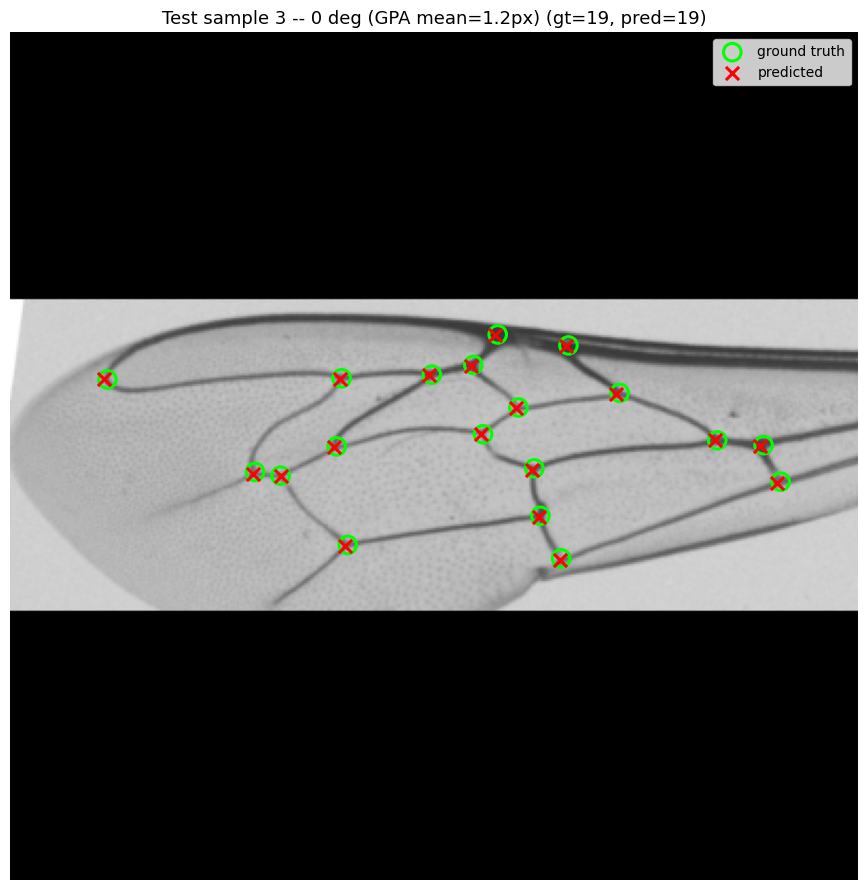

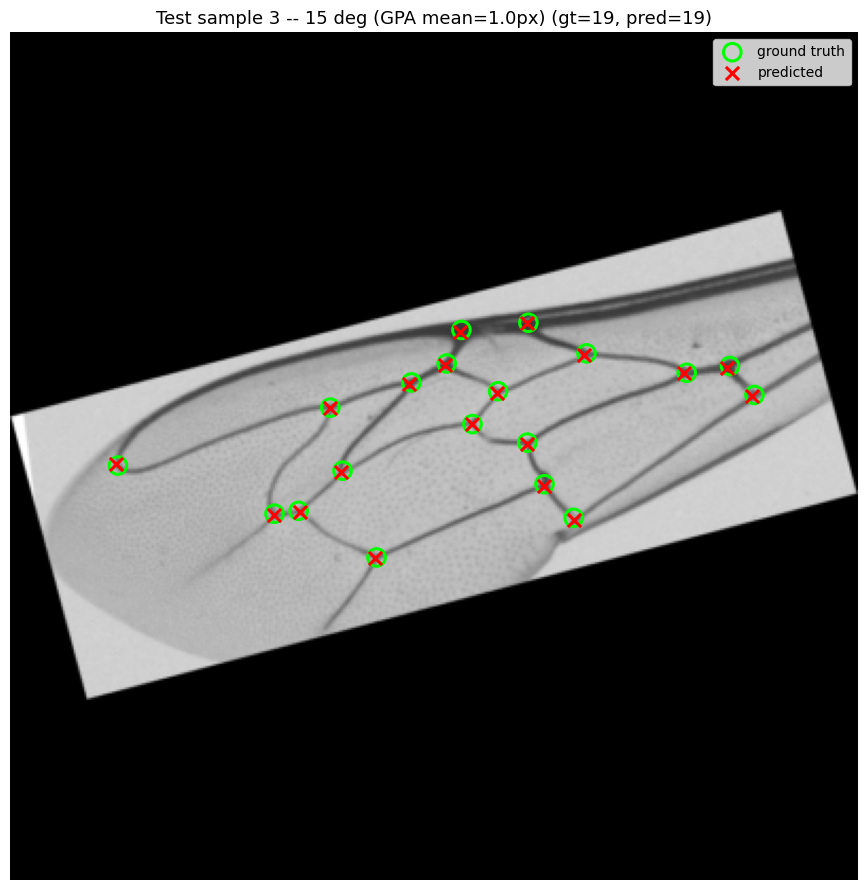

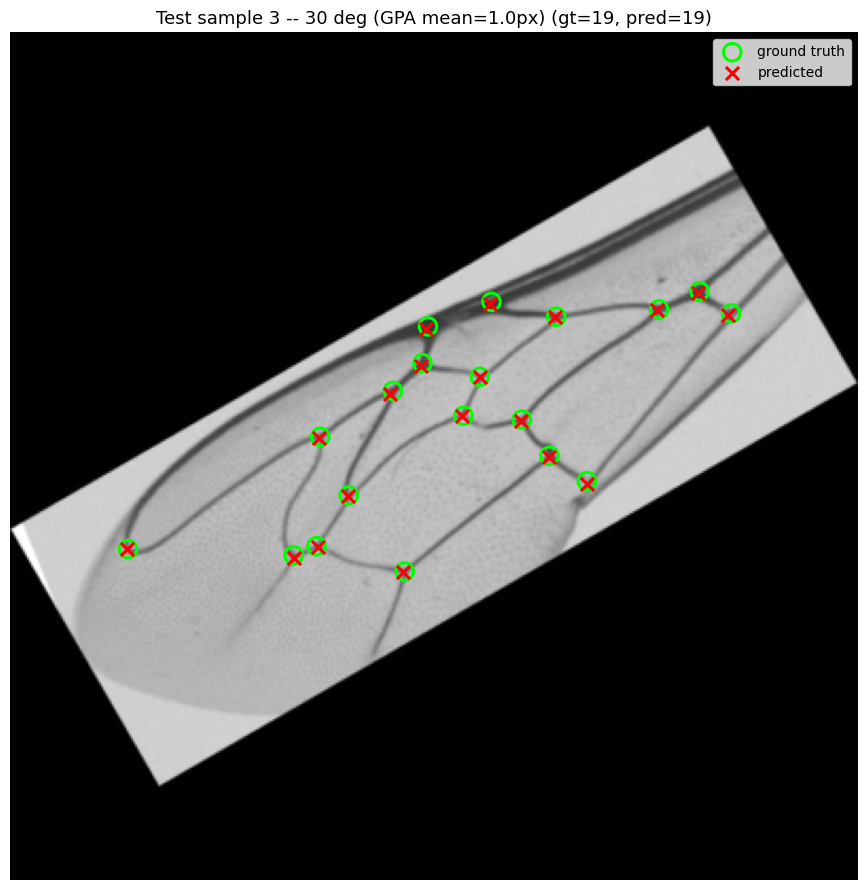

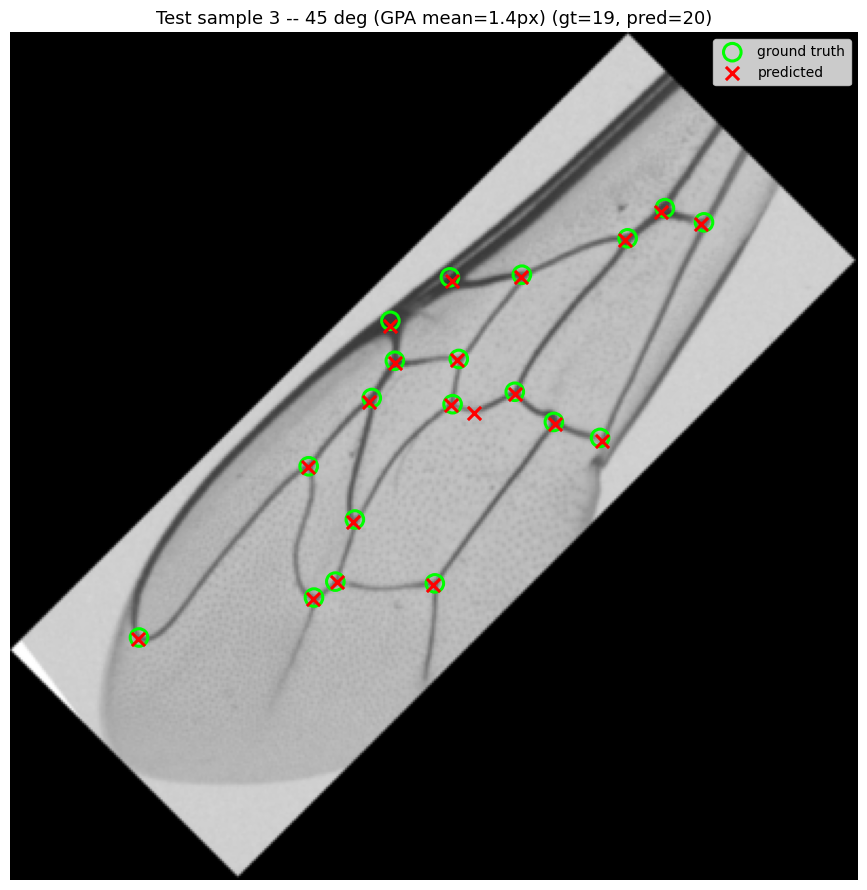

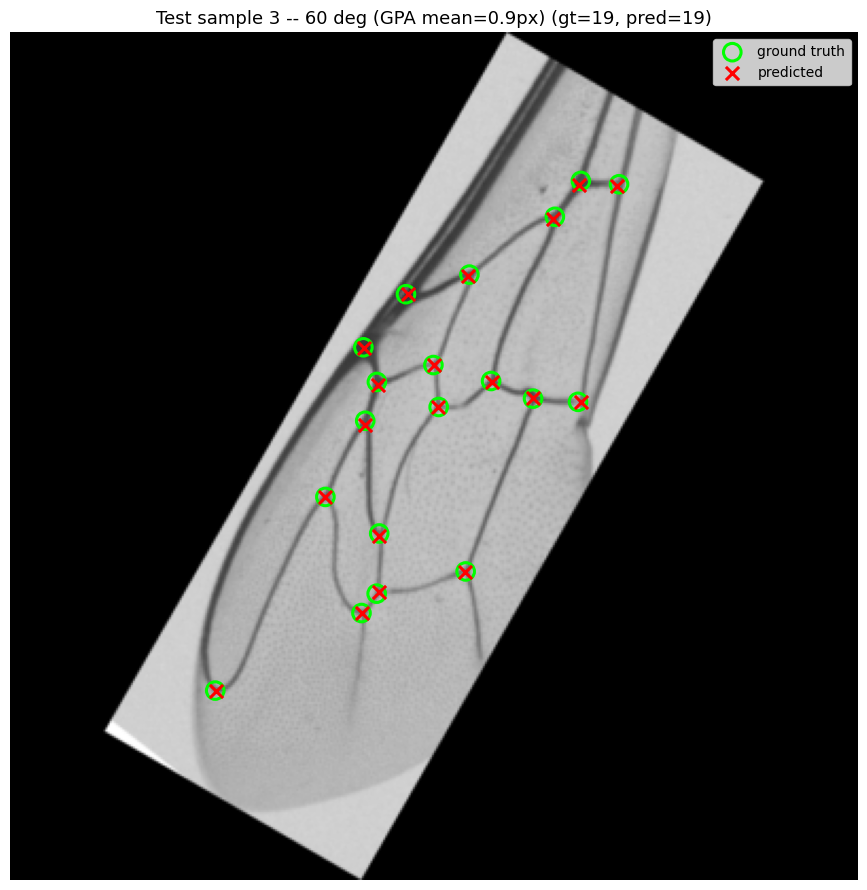

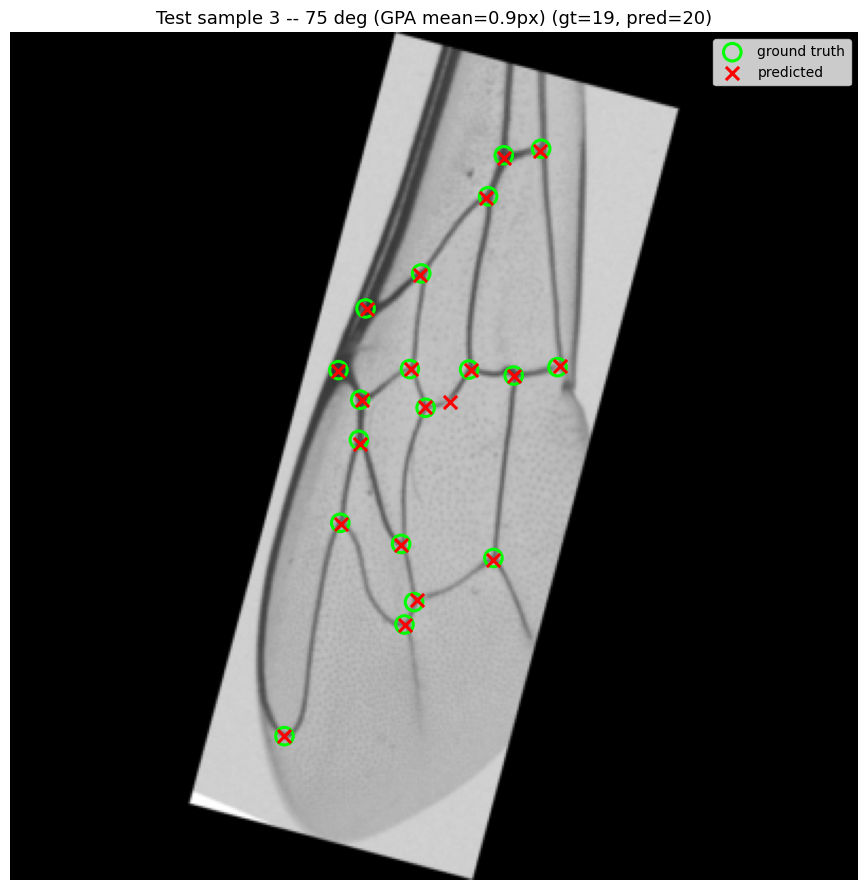

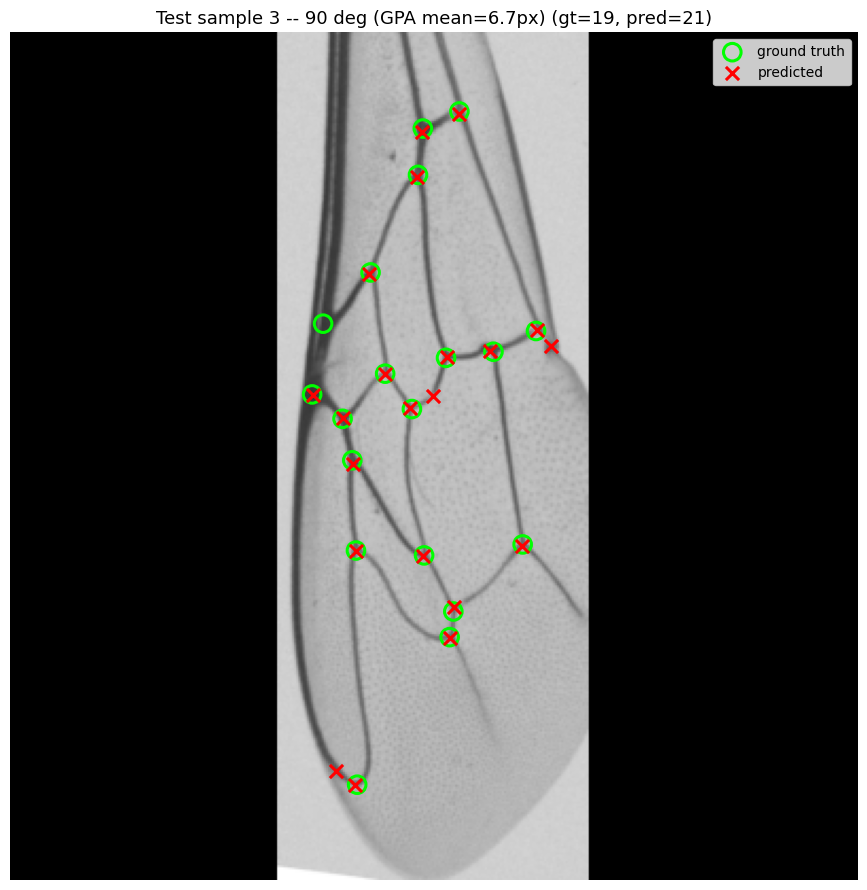

In [4]:
sample_index = 3
angles = [0.0, 15.0, 30.0, 45.0, 60.0, 75.0, 90.0]

for angle in angles:
    cfg = TrainAugmentConfig(rotation_degrees=(angle, angle), horizontal_flip_p=0.0, triangle_noise_p=0.0, color_jitter_p=0.0)
    image, pred_coords, true_ordered = run_sample(sample_index, build_train_transform(OUTPUT_SIZE, cfg))
    d_gpa = gpa_ordered_distances(pred_coords, true_ordered)
    err_str = f"GPA mean={d_gpa.mean().item():.1f}px" if d_gpa is not None else "no prediction"
    show_one(image, pred_coords, true_ordered, f"Test sample {sample_index} -- {angle:.0f} deg ({err_str})")

## Section B -- realistic worst case: full config 4 augmentation severity

Same `TrainAugmentConfig` config 4 actually trains on (`jobs/online/README.md`
"Aug B"): rotation +/-90 deg, horizontal flip 50% of the time, triangle noise
80% of the time (40-240 triangles), color jitter 100% of the time (0.5-1.5x
brightness/contrast). Each image is an independent random draw -- exactly
what the model saw during training, not a cherry-picked easy case -- shown
one after another below. Both accuracy numbers are shown per image; GPA and
nearest-neighbor should now track each other closely even on draws that came
out flipped (mirrored wing), thanks to the `allow_reflection` fix covered in
Section C -- a lingering gap between them would mean something Section C's
fix doesn't cover.

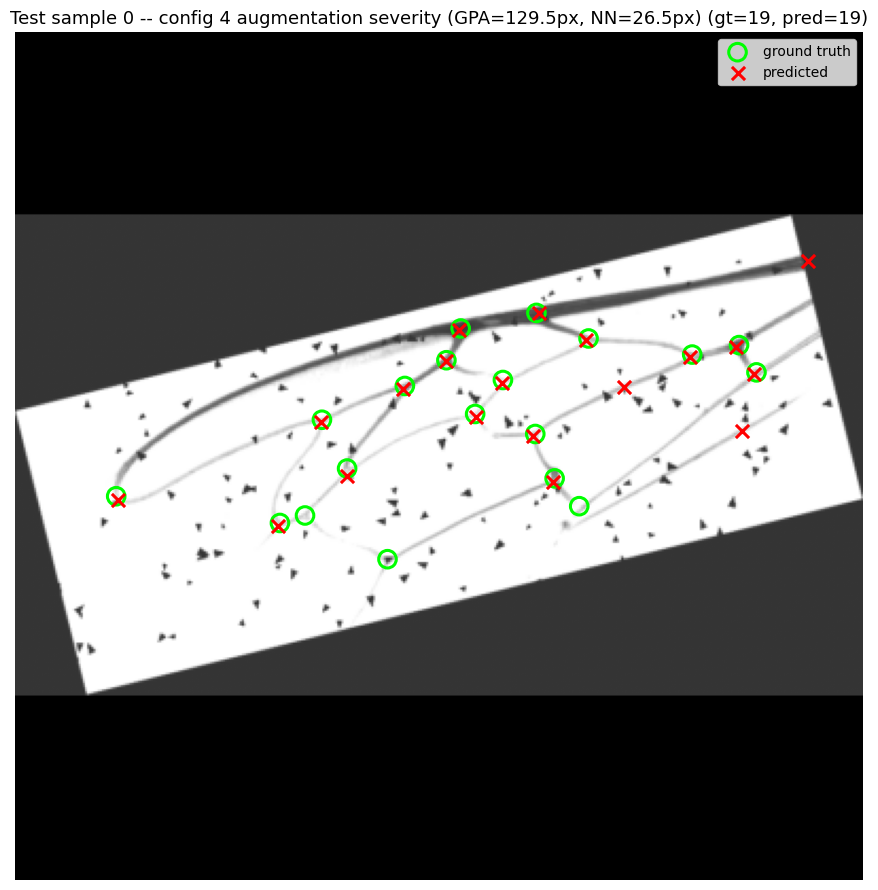

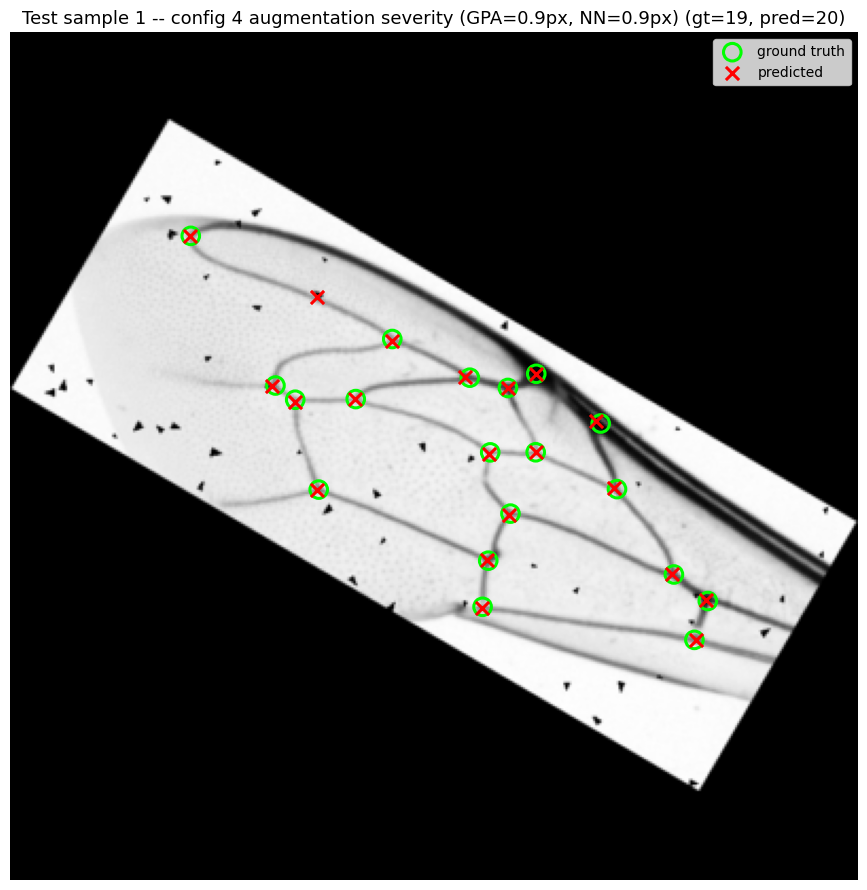

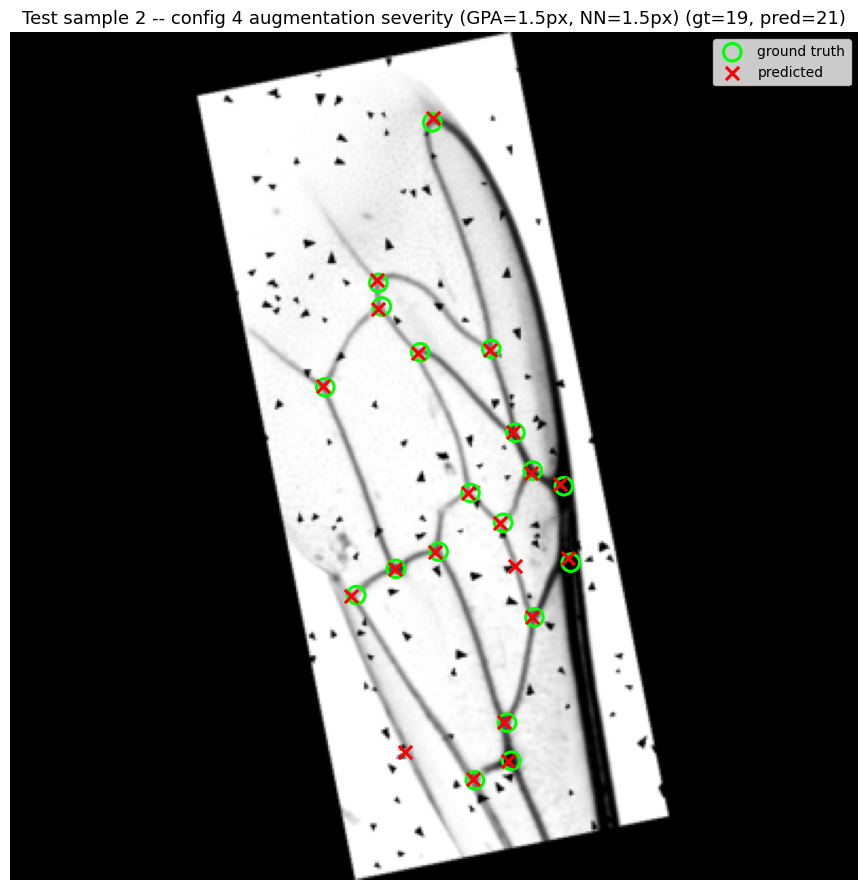

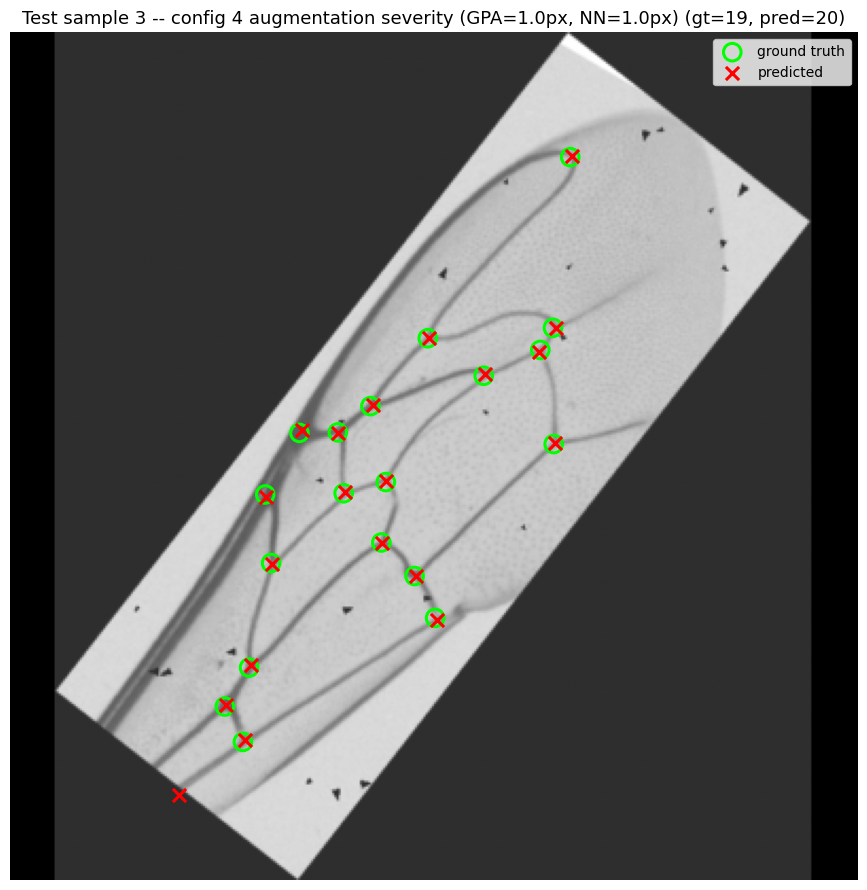

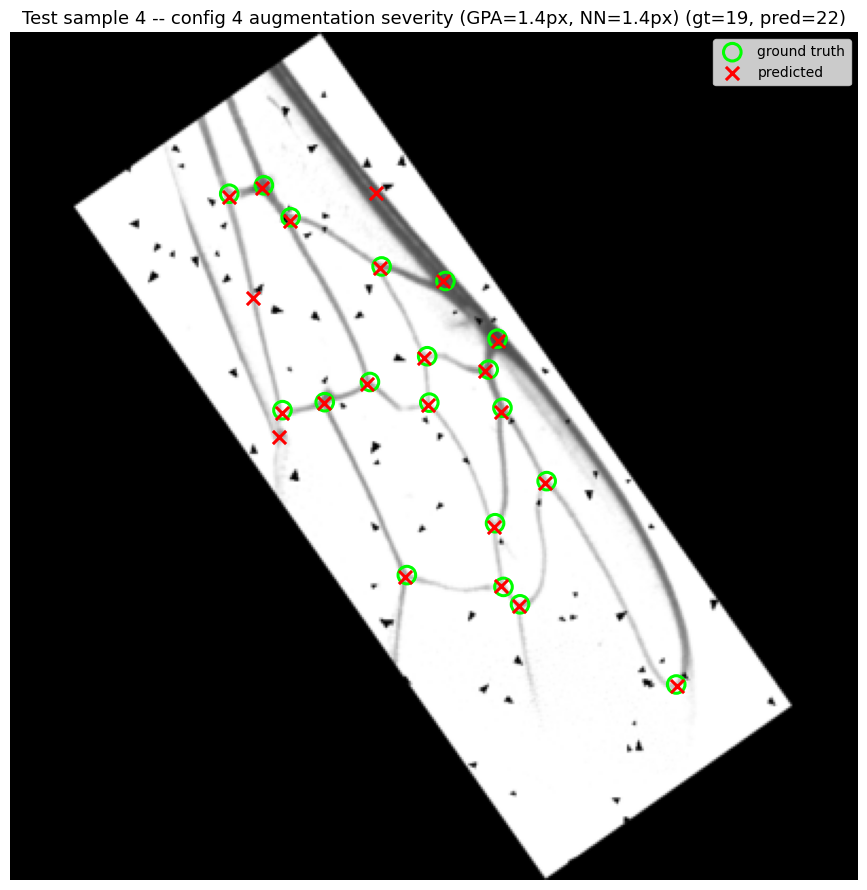

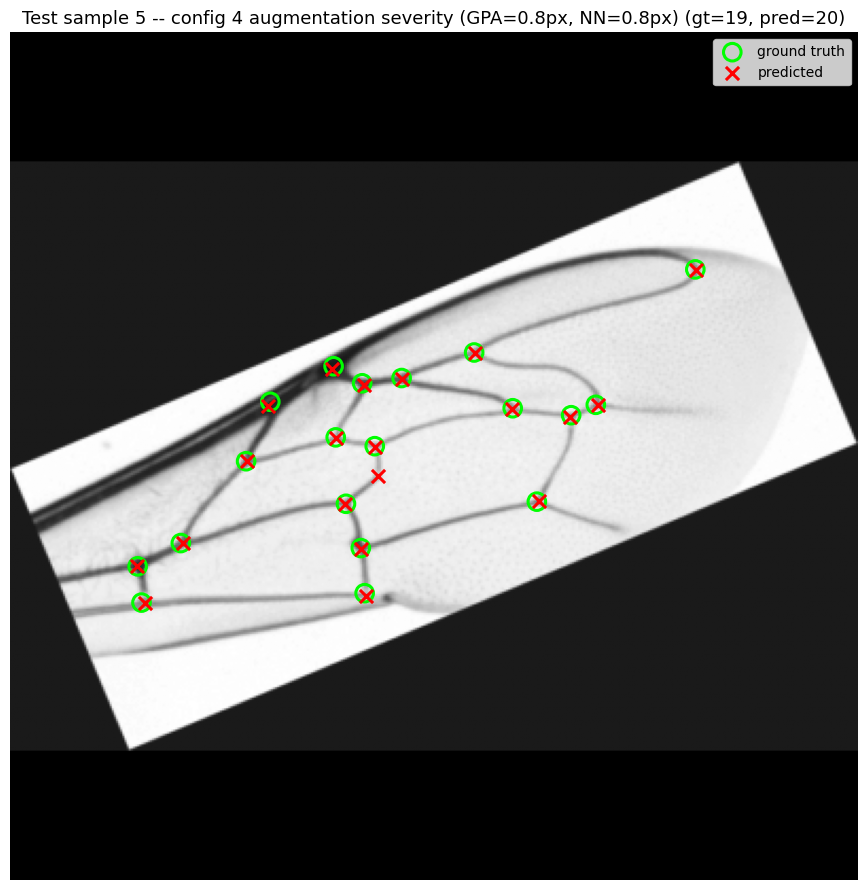

In [5]:
sample_indices = [0, 1, 2, 3, 4, 5]
for idx in sample_indices:
    image, pred_coords, true_ordered = run_sample(idx, aug_b_transform)
    d_gpa = gpa_ordered_distances(pred_coords, true_ordered)
    d_nn = nn_matched_distances(pred_coords, true_ordered)
    gpa_str = f"{d_gpa.mean().item():.1f}px" if d_gpa is not None else "n/a"
    nn_str = f"{d_nn.mean().item():.1f}px" if d_nn is not None else "n/a"
    show_one(image, pred_coords, true_ordered, f"Test sample {idx} -- config 4 augmentation severity (GPA={gpa_str}, NN={nn_str})")

## Section C -- horizontal flip vs. GPA-based ordering (fixed)

`TrainAugmentConfig`'s default `horizontal_flip_p=0.5` means half of
training/test draws are mirror images. `wings/gpa.py`'s `procrustes_align`
used to explicitly exclude reflections (correcting any `det(r) < 0` solution
back to the nearest pure rotation) -- so a prediction from a flipped image
could never be aligned correctly to `mean_coords`, and the GPA ordering step
would converge to a wrong permutation even though segmentation itself was
fine.

**Fixed**: `procrustes_align`/`recover_order`/`handle_coordinates` now take
an `allow_reflection` flag. When set, the alignment step itself is allowed to
use a reflection when that's the better fit (verified standalone: exact
recovery, 0px error, vs. the old ~0.3px average error when a flip is
forced into a rotation-only fit) -- and, since the very first
correspondence guess is otherwise still just a raw nearest-neighbor match on
unaligned points (near-arbitrary for a truly mirrored shape), the whole
search is additionally run once more from a pre-mirrored starting
orientation, keeping whichever of the two converges to the lower residual.
`litnet.py` and `wings/app/images.py` (real inference) now both pass
`allow_reflection=True`, and so does `gpa_ordered_distances` above. This
cell shows the before/after on this exact checkpoint, isolating flip alone
(no rotation, no noise) so the improvement is directly attributable to it.

In [6]:
from wings.gpa import handle_coordinates as _handle_coordinates_raw  # direct access, to show both old and new behavior

def _gpa_mean_error(pred_coords, true_ordered, allow_reflection):
    if len(pred_coords) == 0:
        return None
    pred_t = torch.tensor(pred_coords, dtype=torch.float32)
    reordered = _handle_coordinates_raw(pred_t, mean_coords, allow_reflection=allow_reflection)
    return torch.norm(reordered - true_ordered, dim=1).mean().item()

cfg_noflip = TrainAugmentConfig(rotation_degrees=(0.0, 0.0), horizontal_flip_p=0.0, triangle_noise_p=0.0, color_jitter_p=0.0)
cfg_flip = TrainAugmentConfig(rotation_degrees=(0.0, 0.0), horizontal_flip_p=1.0, triangle_noise_p=0.0, color_jitter_p=0.0)

for label, cfg in [("no flip", cfg_noflip), ("forced flip", cfg_flip)]:
    transform = build_train_transform(OUTPUT_SIZE, cfg)
    old_means, new_means, nn_means = [], [], []
    for idx in range(10):
        _, pred_coords, true_ordered = run_sample(idx, transform)
        old = _gpa_mean_error(pred_coords, true_ordered, allow_reflection=False)
        new = _gpa_mean_error(pred_coords, true_ordered, allow_reflection=True)
        d_nn = nn_matched_distances(pred_coords, true_ordered)
        if old is not None:
            old_means.append(old)
        if new is not None:
            new_means.append(new)
        if d_nn is not None:
            nn_means.append(d_nn.mean().item())
    print(f"{label:12s}  GPA (old, rotation-only)={np.mean(old_means):7.2f}px   "
          f"GPA (fixed, allow_reflection)={np.mean(new_means):6.2f}px   "
          f"nearest-neighbor={np.mean(nn_means):6.2f}px   (avg over 10 samples)")

no flip       GPA (old, rotation-only)=   1.03px   GPA (fixed, allow_reflection)=  1.03px   nearest-neighbor=  1.03px   (avg over 10 samples)


forced flip   GPA (old, rotation-only)= 124.00px   GPA (fixed, allow_reflection)=  0.88px   nearest-neighbor=  0.88px   (avg over 10 samples)


For "no flip," old and fixed GPA should match (nothing to fix when
there's no reflection). For "forced flip," the fixed GPA number should drop
to roughly match nearest-neighbor -- confirming the ordering step now
recovers the correct landmark identities instead of a wrong permutation.

## Section D -- error vs. rotation angle (quantitative)

Both GPA-ordered and nearest-neighbor mean/median error across several test
samples at each fixed rotation angle (flip forced off, isolating rotation's
effect specifically -- see Section C for flip's separate effect). Watch for
GPA-ordered and nearest-neighbor diverging at some angle: that means the
segmentation is still accurate there, but the GPA step is struggling for a
reason unrelated to segmentation quality (as turned out to be the case for
this notebook's own earlier bug, and confirmed a real phenomenon for flip
above).

angle=  0.0  GPA mean=  1.055 median=  1.026   NN mean=  1.055 median=  1.026


angle= 15.0  GPA mean=  0.947 median=  0.910   NN mean=  0.942 median=  0.910


angle= 30.0  GPA mean=  1.076 median=  0.912   NN mean=  1.054 median=  0.904


angle= 45.0  GPA mean=  4.539 median=  1.077   NN mean=  1.174 median=  1.015


angle= 60.0  GPA mean=  3.053 median=  1.001   NN mean=  1.052 median=  0.981


angle= 75.0  GPA mean=  1.069 median=  0.964   NN mean=  1.069 median=  0.964


angle= 90.0  GPA mean= 12.732 median=  1.151   NN mean=  2.543 median=  0.954


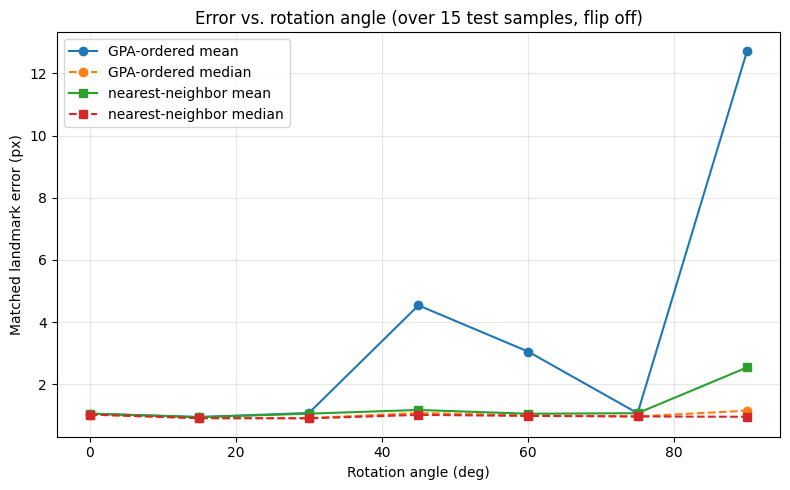

In [7]:
angles = [0.0, 15.0, 30.0, 45.0, 60.0, 75.0, 90.0]
n_samples = 15

gpa_means, gpa_medians, nn_means, nn_medians = [], [], [], []
for angle in angles:
    cfg = TrainAugmentConfig(rotation_degrees=(angle, angle), horizontal_flip_p=0.0, triangle_noise_p=0.0, color_jitter_p=0.0)
    transform = build_train_transform(OUTPUT_SIZE, cfg)
    gpa_d, nn_d = [], []
    for idx in range(n_samples):
        _, pred_coords, true_ordered = run_sample(idx, transform)
        d_gpa = gpa_ordered_distances(pred_coords, true_ordered)
        d_nn = nn_matched_distances(pred_coords, true_ordered)
        if d_gpa is not None:
            gpa_d.append(d_gpa)
        if d_nn is not None:
            nn_d.append(d_nn)
    gpa_cat = torch.cat(gpa_d) if gpa_d else torch.tensor([])
    nn_cat = torch.cat(nn_d) if nn_d else torch.tensor([])
    gpa_means.append(gpa_cat.mean().item() if len(gpa_cat) else float("nan"))
    gpa_medians.append(gpa_cat.median().item() if len(gpa_cat) else float("nan"))
    nn_means.append(nn_cat.mean().item() if len(nn_cat) else float("nan"))
    nn_medians.append(nn_cat.median().item() if len(nn_cat) else float("nan"))
    print(f"angle={angle:>5.1f}  GPA mean={gpa_means[-1]:7.3f} median={gpa_medians[-1]:7.3f}   "
          f"NN mean={nn_means[-1]:7.3f} median={nn_medians[-1]:7.3f}")

plt.figure(figsize=(8, 5))
plt.plot(angles, gpa_means, marker="o", label="GPA-ordered mean")
plt.plot(angles, gpa_medians, marker="o", linestyle="--", label="GPA-ordered median")
plt.plot(angles, nn_means, marker="s", label="nearest-neighbor mean")
plt.plot(angles, nn_medians, marker="s", linestyle="--", label="nearest-neighbor median")
plt.xlabel("Rotation angle (deg)")
plt.ylabel("Matched landmark error (px)")
plt.title(f"Error vs. rotation angle (over {n_samples} test samples, flip off)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section E -- deep dive on one angle

If Section D shows a jump at some particular angle that doesn't look like a
smooth continuation of the surrounding trend, that's worth looking at
directly rather than trusting the average -- a mean over just `n_samples`
can be dominated by one or two hard points rather than reflecting a genuine,
uniform weakness at that angle. Set `DEEP_DIVE_ANGLE` below to whichever
angle looked off in Section D (defaults to 90). Each sample shows both
accuracy numbers plus the predicted/ground-truth counts.

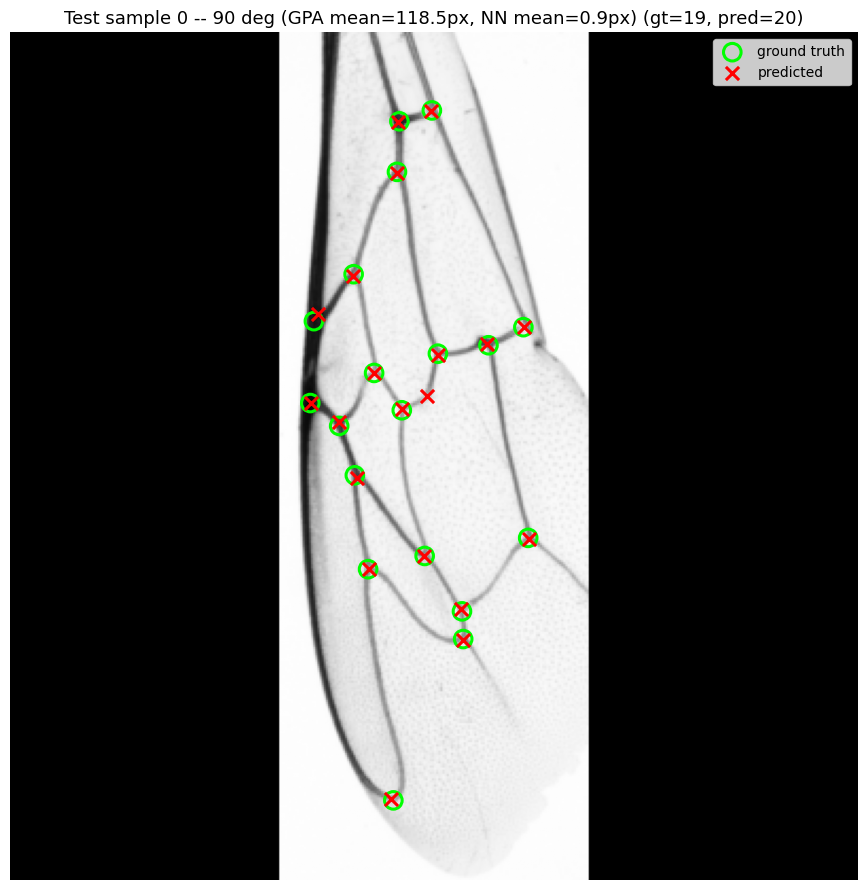

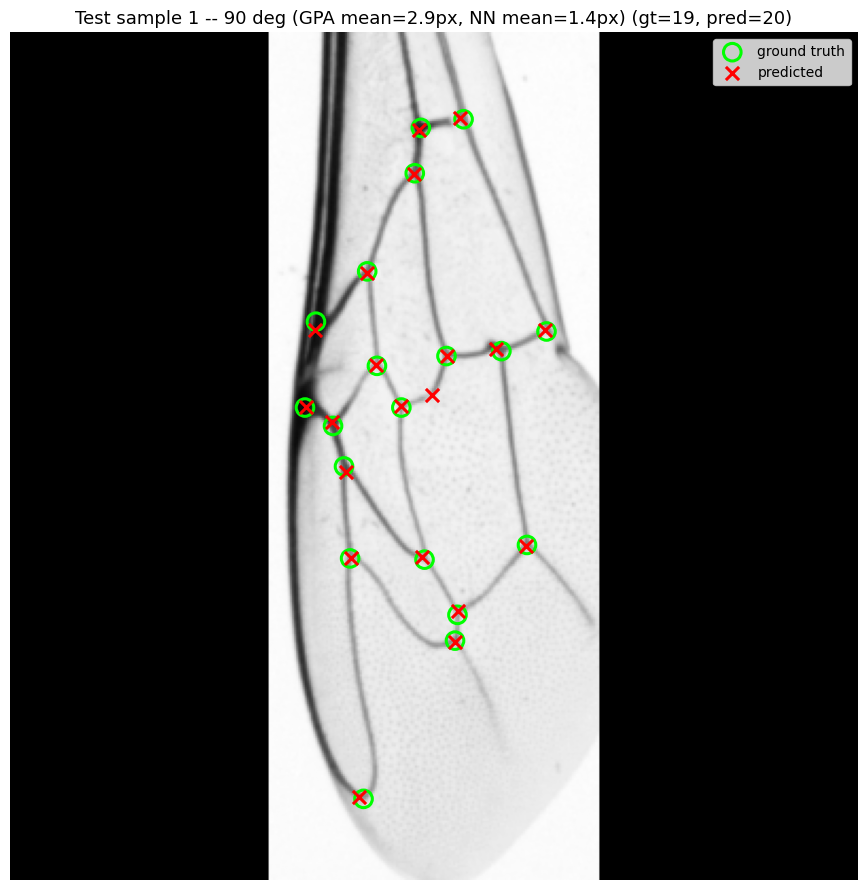

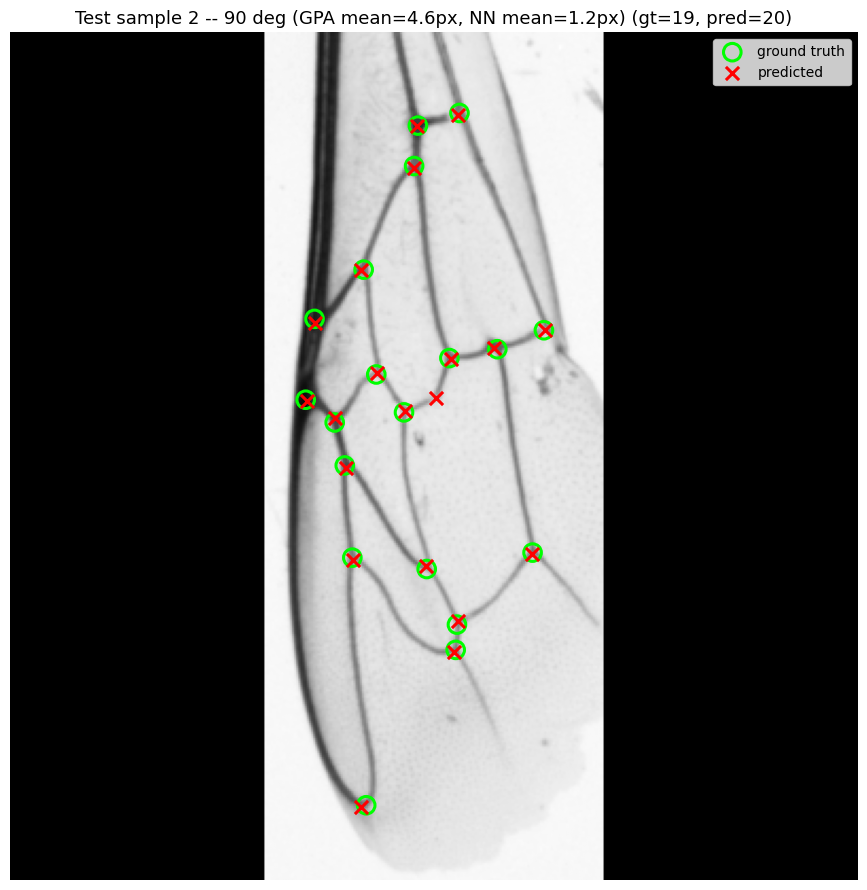

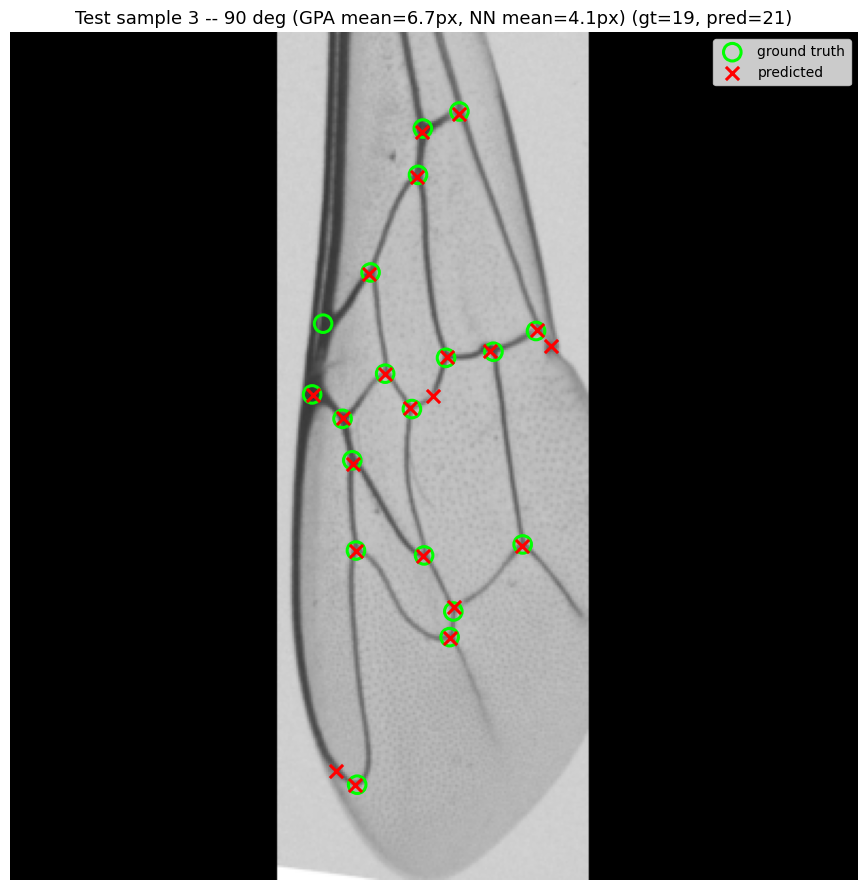

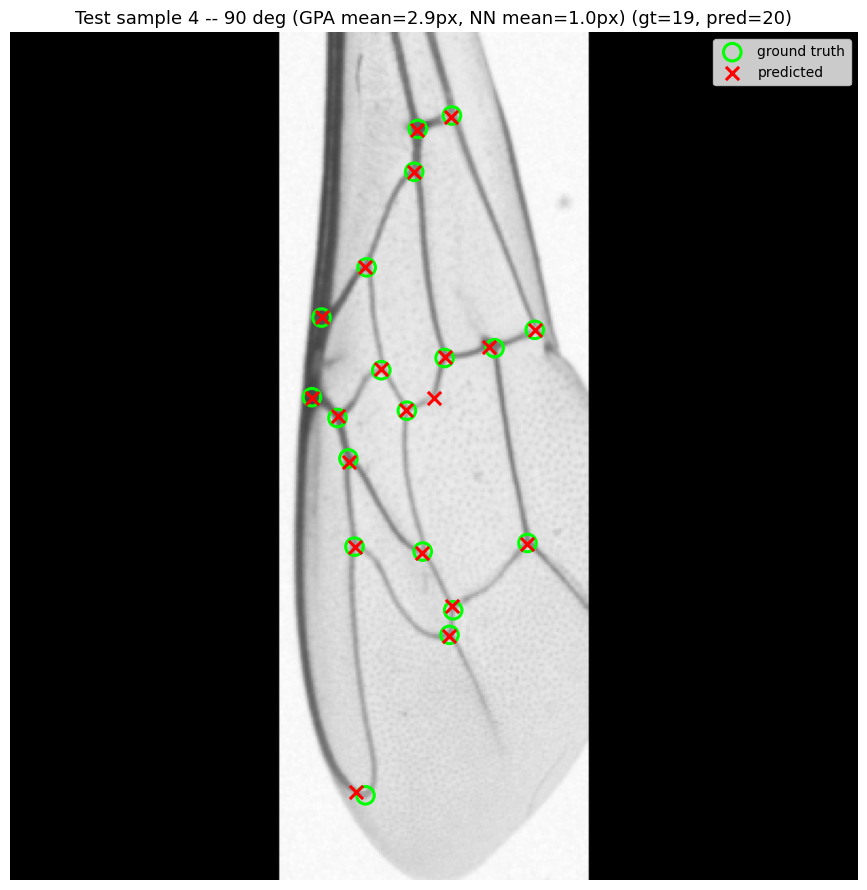

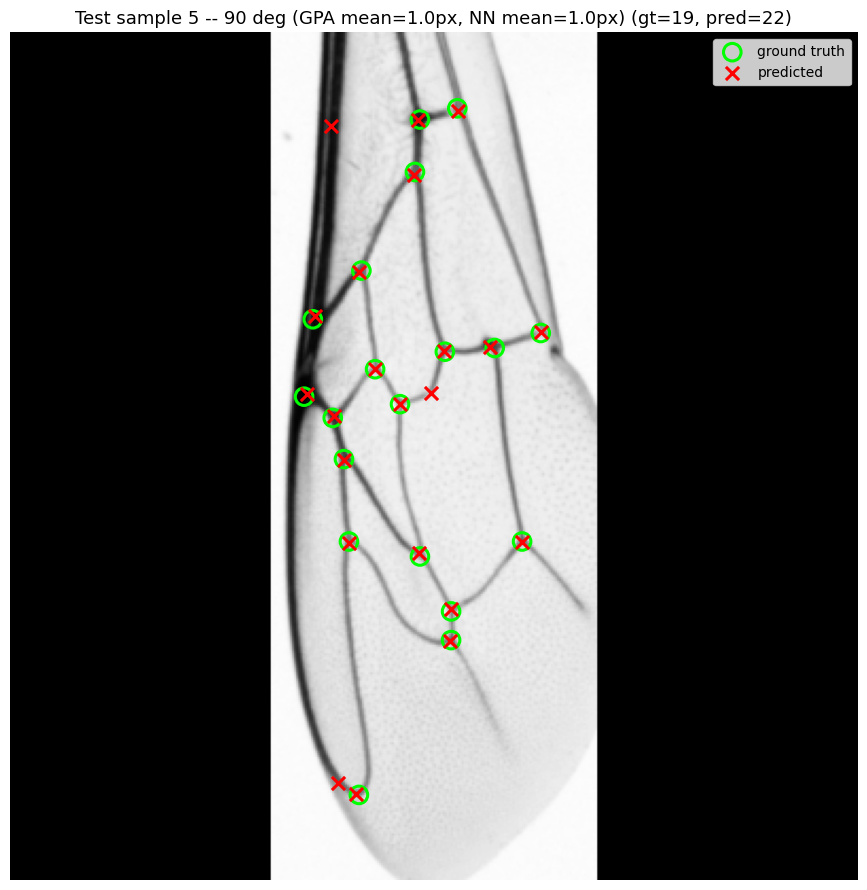

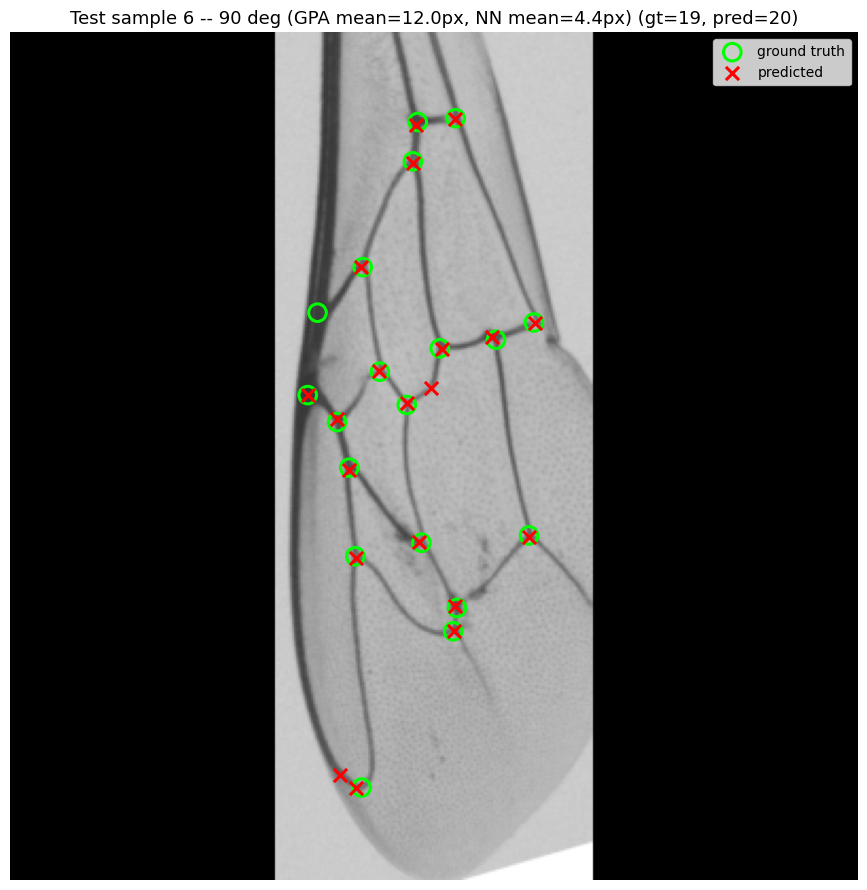

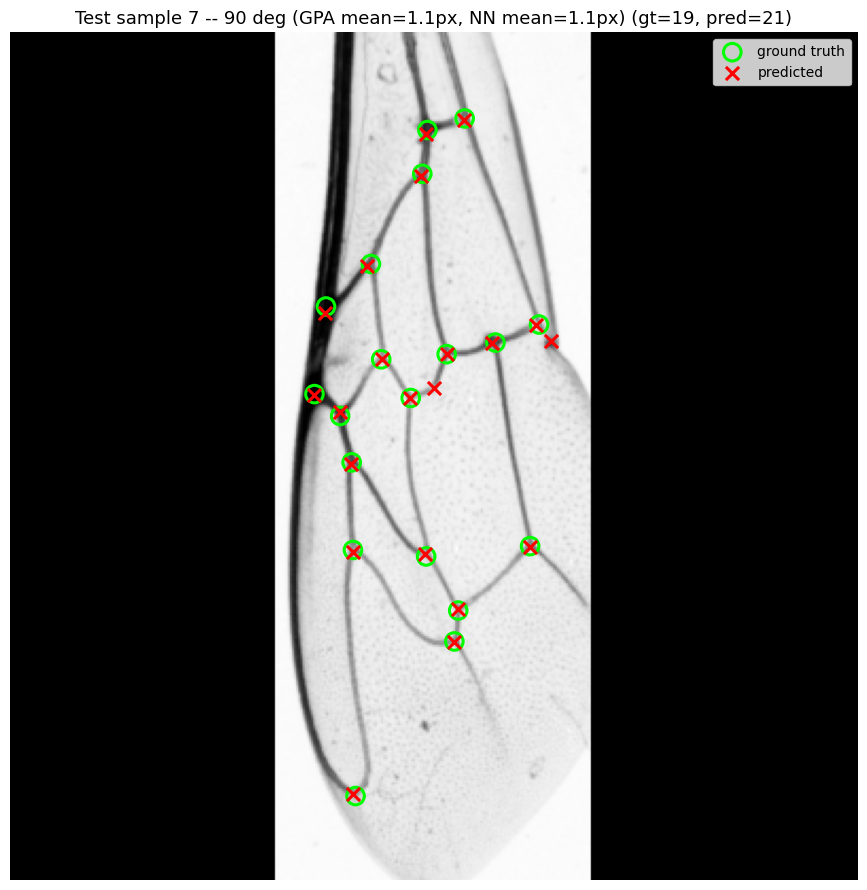

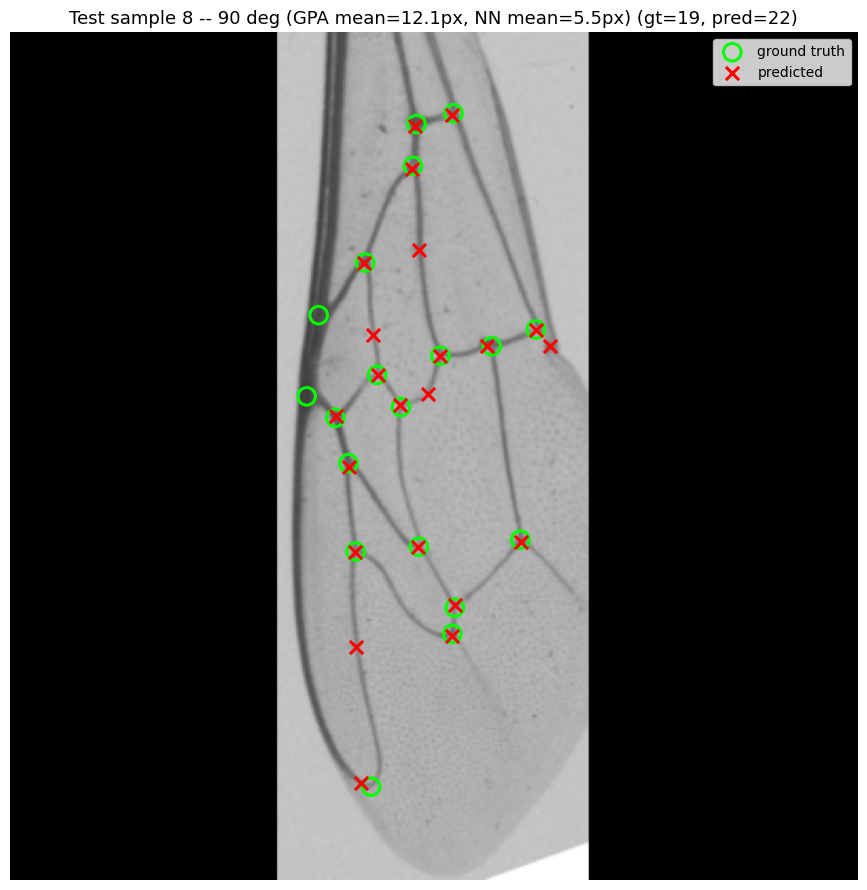

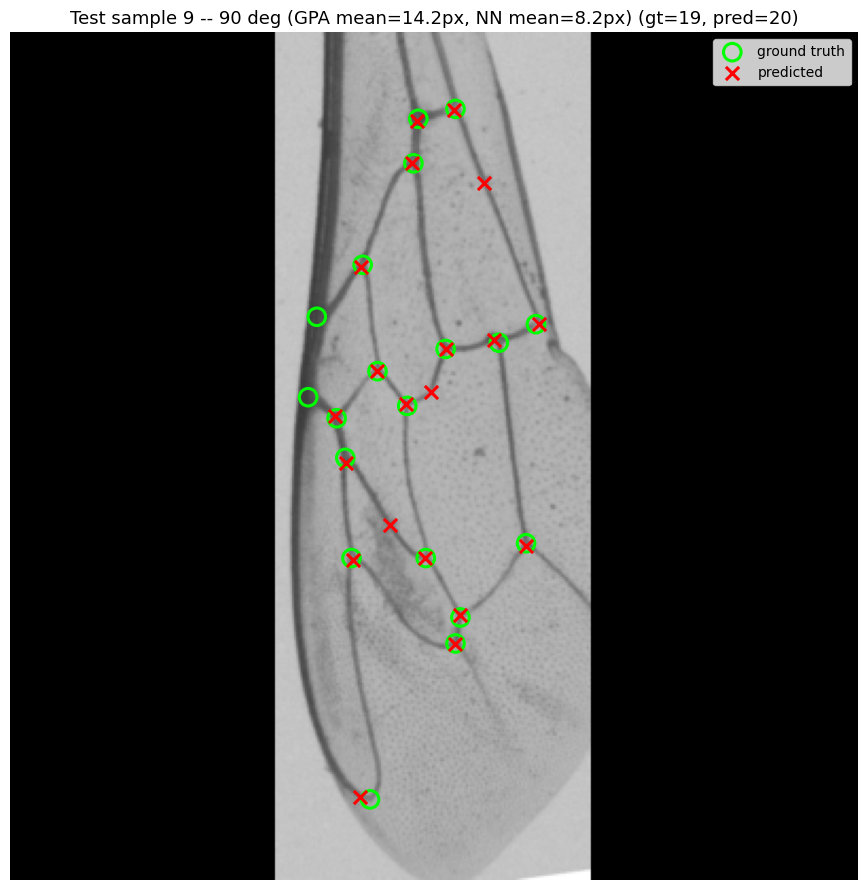

In [8]:
DEEP_DIVE_ANGLE = 90.0
n_deep_dive_samples = 10

deep_dive_cfg = TrainAugmentConfig(rotation_degrees=(DEEP_DIVE_ANGLE, DEEP_DIVE_ANGLE), horizontal_flip_p=0.0, triangle_noise_p=0.0, color_jitter_p=0.0)
deep_dive_transform = build_train_transform(OUTPUT_SIZE, deep_dive_cfg)

for idx in range(n_deep_dive_samples):
    image, pred_coords, true_ordered = run_sample(idx, deep_dive_transform)
    d_gpa = gpa_ordered_distances(pred_coords, true_ordered)
    d_nn = nn_matched_distances(pred_coords, true_ordered)
    gpa_str = f"GPA mean={d_gpa.mean().item():.1f}px" if d_gpa is not None else "GPA n/a"
    nn_str = f"NN mean={d_nn.mean().item():.1f}px" if d_nn is not None else "NN n/a"
    show_one(image, pred_coords, true_ordered, f"Test sample {idx} -- {DEEP_DIVE_ANGLE:.0f} deg ({gpa_str}, {nn_str})")

## Section F -- interactive: re-run for a new random example

**Just re-run this cell** (select it, press Ctrl+Enter / the Run button)
repeatedly -- each execution picks a different random test image and a fresh
random draw of config 4's actual augmentation (new rotation angle, possible
flip, new triangle noise, new color jitter), runs the model, and shows the
overlay with both accuracy numbers. No setup needed beyond running the cells
above once.

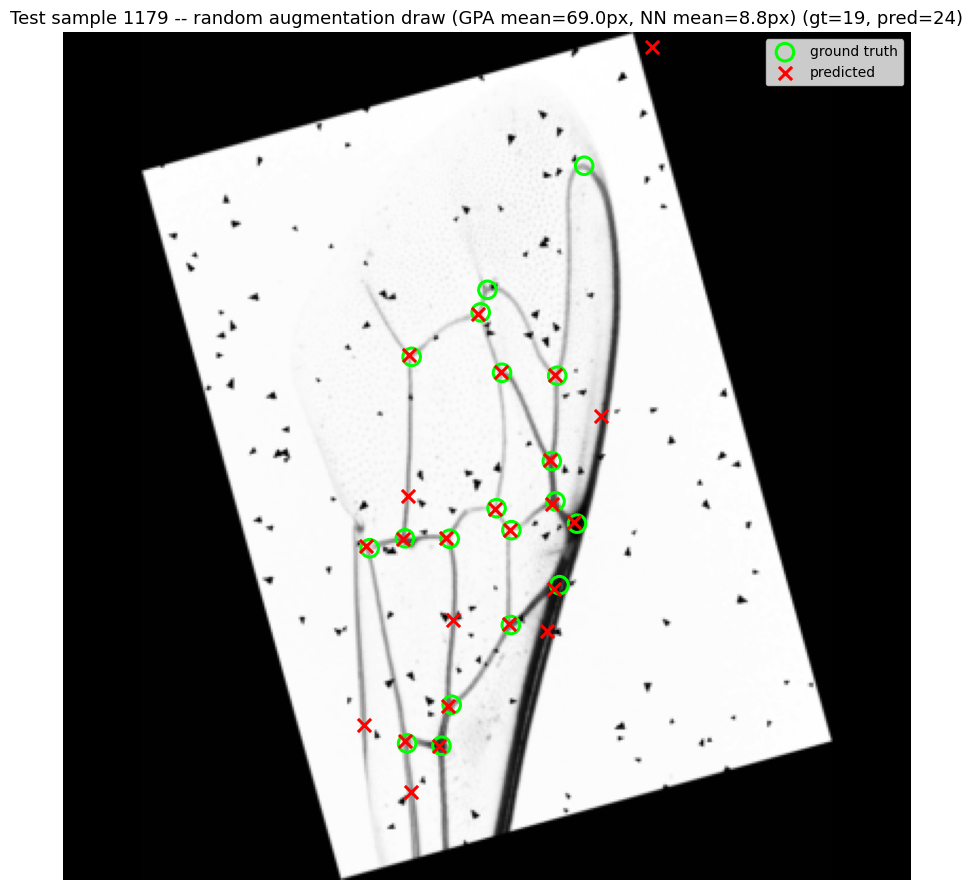

In [9]:
idx = random.randrange(len(test_idx))
image, pred_coords, true_ordered = run_sample(idx, aug_b_transform)
d_gpa = gpa_ordered_distances(pred_coords, true_ordered)
d_nn = nn_matched_distances(pred_coords, true_ordered)
gpa_str = f"GPA mean={d_gpa.mean().item():.1f}px" if d_gpa is not None else "GPA n/a"
nn_str = f"NN mean={d_nn.mean().item():.1f}px" if d_nn is not None else "NN n/a"
show_one(image, pred_coords, true_ordered, f"Test sample {idx} -- random augmentation draw ({gpa_str}, {nn_str})")

## Summary

- Section A shows whether error visibly grows with rotation magnitude for one
  fixed sample -- a rising red-x/green-o gap at 60-90 deg vs. 0 deg would flag
  the model is still weaker on extreme angles despite training on them.
- Section B is the realistic check: this is the actual distribution the model
  trains on, so this is the most representative "how good is it really" view.
- Section C shows flip's effect on GPA ordering, before and after the
  `allow_reflection` fix in `wings/gpa.py` -- this is why GPA and NN no
  longer diverge on flipped draws elsewhere in this notebook.
- Section D turns the rotation sweep into numbers (mean *and* median, GPA
  *and* nearest-neighbor): a roughly flat GPA line tracking the NN line means
  rotation robustness is genuinely learned end-to-end; GPA climbing while NN
  stays flat means the segmentation is fine but the ordering step is
  struggling.
- Section E digs into any single suspicious angle from Section D sample by
  sample, to tell a genuine per-angle weakness apart from a couple of hard
  points skewing the average.
- Section F is for freely browsing -- keep re-running it to build intuition
  across many random test images/augmentation draws.
- Checking a different/future checkpoint later: update `CHECKPOINT_PATH` in
  the Setup cell (and `MODEL_SIGMOID` if it uses a WeightedDiceLoss-style
  config like 1/3 instead of BCEDiceLoss like 4).